1: Import Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import savgol_filter
from scipy.optimize import lsq_linear

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla V100-SXM2-16GB


2: Data Loading and Extended Feature Construction

In [ ]:
data = np.load('dataset2.npz')
wavenumber_axis = data['wavenumber_axis']
composite = data['composite']
alpha_helix = data['alpha_helix']
beta_sheet_lo = data['beta_sheet_lo']
beta_sheet_hi = data['beta_sheet_hi']
beta_turn_lo = data['beta_turn_lo']
beta_turn_hi = data['beta_turn_hi']
other_peaks = data['other_peaks']

N, L = composite.shape
print(f"Dataset loaded: {N} samples, {L} wavenumber points")
print(f"Wavenumber range: {wavenumber_axis.min():.1f} - {wavenumber_axis.max():.1f} cm⁻¹")

# update the peak table to match the new wavenumber range
peak_table_flat = [
    ("beta_sheet", 1624), ("beta_sheet", 1627), ("beta_sheet", 1633),
    ("beta_sheet", 1638), ("beta_sheet", 1642), ("beta_sheet", 1691),
    ("beta_sheet", 1696), ("alpha_helix", 1656),
    ("beta_turn", 1667), ("beta_turn", 1675), ("beta_turn", 1680), ("beta_turn", 1685),
]

# verify if the peaks are within the wavenumber range
valid_peaks = []
for peak_type, center in peak_table_flat:
    if wavenumber_axis.min() <= center <= wavenumber_axis.max():
        valid_peaks.append((peak_type, center))
    else:
        print(f"Warning: Peak {peak_type} at {center} cm⁻¹ is outside wavenumber range")

if len(valid_peaks) < len(peak_table_flat):
    print(f"Using {len(valid_peaks)} valid peaks out of {len(peak_table_flat)} original peaks")
    peak_table_flat = valid_peaks

delta = 2.0
def extract_integral_features(spectrum, wavenumber_axis, peak_table_flat, delta=2.0):
    """
    Extract extended statistical features within peak regions
    Including: integral, maximum, mean, median, standard deviation, variance, minimum, skewness, kurtosis
    """
    features = []
    for _, center in peak_table_flat:
        mask = (wavenumber_axis >= center - delta) & (wavenumber_axis <= center + delta)
        if np.any(mask):
            peak_region = spectrum[mask]
            if len(peak_region) > 0:
                # Basic statistical features
                integral = peak_region.sum()  # Integral
                max_val = peak_region.max()   # Maximum
                min_val = peak_region.min()   # Minimum
                mean_val = peak_region.mean() # Mean
                median_val = np.median(peak_region)  # Median
                
                # Variance and standard deviation
                var_val = peak_region.var()
                std_val = peak_region.std()
                
                # Skewness and kurtosis (requires at least 3 points)
                if len(peak_region) >= 3:
                    skewness = ((peak_region - mean_val) ** 3).mean() / (std_val ** 3) if std_val > 0 else 0
                    kurtosis = ((peak_region - mean_val) ** 4).mean() / (std_val ** 4) if std_val > 0 else 0
                else:
                    skewness = 0
                    kurtosis = 0
                
                # Combine all features
                peak_features = [
                    integral, max_val, min_val, mean_val, median_val,
                    var_val, std_val, skewness, kurtosis
                ]
            else:
                peak_features = [0.0] * 9  # Set all 9 features to 0
        else:
            peak_features = [0.0] * 9  # Set all 9 features to 0
        
        features.extend(peak_features)
    
    return np.array(features)
X_integral = np.stack([
    extract_integral_features(s, wavenumber_axis, peak_table_flat, delta=delta)
    for s in composite
])

# Feature dimension explanation:
# Each peak region extracts 9 features: integral, maximum, minimum, mean, median, variance, standard deviation, skewness, kurtosis
# Total of 12 peak regions, so feature dimension is 12 * 9 = 108
print(f"Statistical feature dimension: {X_integral.shape[1]} (9 features per peak region × {len(peak_table_flat)} peak regions)")


Dataset loaded: 10000 samples, 1601 wavenumber points
Wavenumber range: 1570.0 - 1730.0 cm⁻¹
Statistical feature dimension: 108 (9 features per peak region × 12 peak regions)


3: Peak Table Definition

In [ ]:
peak_table = {
    "beta_sheet": [
        (1624, 1.0, 12.0), (1627, 2.0, 12.0), (1633, 2.0, 12.0),
        (1638, 2.0, 12.0), (1642, 1.0, 12.0), (1691, 2.0, 12.0), (1696, 2.0, 12.0)
    ],
    "alpha_helix": [(1656, 2.0, 12.0)],
    "beta_turn": [
        (1667, 1.0, 12.0), (1675, 1.0, 12.0), (1680, 2.0, 12.0), (1685, 2.0, 12.0)
    ],
}

# 添加新的峰值检测函数，利用分解后的光谱数据
def extract_decomposed_features(spectrum, wavenumber_axis, peak_table, delta=2.0):
    features = []
    
    # 为每个峰值区域提取特征
    for _, center in peak_table_flat:
        mask = (wavenumber_axis >= center - delta) & (wavenumber_axis <= center + delta)
        if np.any(mask):
            peak_region = spectrum[mask]
            if len(peak_region) > 0:
                # 基本统计特征
                integral = peak_region.sum()
                max_val = peak_region.max()
                min_val = peak_region.min()
                mean_val = peak_region.mean()
                median_val = np.median(peak_region)
                
                # 方差和标准差
                var_val = peak_region.var()
                std_val = peak_region.std()
                
                # 偏度和峰度
                if len(peak_region) >= 3:
                    skewness = ((peak_region - mean_val) ** 3).mean() / (std_val ** 3) if std_val > 0 else 0
                    kurtosis = ((peak_region - mean_val) ** 4).mean() / (std_val ** 4) if std_val > 0 else 0
                else:
                    skewness = 0
                    kurtosis = 0
                
                peak_features = [
                    integral, max_val, min_val, mean_val, median_val,
                    var_val, std_val, skewness, kurtosis
                ]
            else:
                peak_features = [0.0] * 9
        else:
            peak_features = [0.0] * 9
        
        features.extend(peak_features)
    
    return np.array(features)

3.5: Peak Detection and Classification Functions

In [5]:
def detect_peaks(y, x_axis, threshold=0.2, window=20, min_distance=50):
    y_smooth = savgol_filter(y, window_length=21, polyorder=3)
    dy = np.gradient(y_smooth)
    d2y = np.gradient(dy)
    candidates = []
    for i in range(1, len(y_smooth)-1):
        if dy[i-1] > 0 and dy[i+1] < 0 and d2y[i] < 0 and y_smooth[i] > threshold:
            candidates.append(i)
    filtered = []
    for idx in candidates:
        left = max(0, idx-window)
        right = min(len(y_smooth), idx+window)
        if y_smooth[idx] == np.max(y_smooth[left:right]):
            filtered.append(idx)
    final = []
    last_idx = -min_distance
    for idx in filtered:
        if idx - last_idx >= min_distance:
            final.append(idx)
            last_idx = idx
    return np.array(final), y_smooth

def classify_peak(peak_wavenumber, peak_table, delta_multiplier=1.2):
    for family, peaks in peak_table.items():
        for center, delta, gamma in peaks:
            wide_delta = max(delta, 1.5) * delta_multiplier
            if abs(peak_wavenumber - center) <= wide_delta:
                return family, gamma
    return None, None

def lorentzian(x, x0, gamma):
    return 1 / (1 + ((x - x0) / (gamma / 2))**2)

def lorentzian_area(amplitude, gamma):
    """Calculate the area of Lorentzian function: area = π * γ * A / 2"""
    return np.pi * gamma * amplitude / 2

def extract_nnls_fitting_features(spectrum, wavenumber_axis, peak_table, gamma_width=31):
    """
    Extract extended features based on NNLS fitting
    Including: peak position, amplitude, area, peak width, fitting residuals, R², etc.
    
    Parameters:
    -----------
    spectrum : array
        Spectral data
    wavenumber_axis : array
        Wavenumber axis
    peak_table : dict
        Peak table
    gamma_width : float
        Default peak width
    
    Returns:
    --------
    features : array
        Fitting feature vector
    """
    # Peak detection
    peak_indices, y_smooth = detect_peaks(spectrum, wavenumber_axis, 
                                         threshold=0.2, window=20, min_distance=50)
    detected_positions = wavenumber_axis[peak_indices]
    
    # Peak classification
    selected_centers, selected_types, selected_gammas = [], [], []
    for p in detected_positions:
        fam, gamma = classify_peak(p, peak_table)
        if fam is not None:
            selected_centers.append(p)
            selected_types.append(fam)
            selected_gammas.append(gamma)
    
    selected_centers = np.array(selected_centers)
    selected_types = np.array(selected_types)
    selected_gammas = np.array(selected_gammas)
    
    # Initialize fixed-length feature vector
    total_features = 12 * 7 + 7  # 12 peaks × 7 features + 7 global features
    features = np.zeros(total_features)
    
    # If no peaks detected, return zero features
    if len(selected_centers) == 0:
        return features
    
    # NNLS fitting
    B = np.stack([lorentzian(wavenumber_axis, c, g) for c, g in zip(selected_centers, selected_gammas)], axis=1)
    B /= B.max(axis=0, keepdims=True)
    res = lsq_linear(B, spectrum, bounds=(0, np.inf), lsq_solver='exact')
    amplitudes = res.x
    
    # Calculate fitting residuals and R²
    recon = B @ amplitudes
    residuals = spectrum - recon
    mse = np.mean(residuals**2)
    ss_tot = np.sum((spectrum - np.mean(spectrum))**2)
    ss_res = np.sum(residuals**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Calculate area for each peak
    areas = lorentzian_area(amplitudes, selected_gammas)
    
    # Fill peak features (maximum 12 peaks)
    for i, (center, amp, area, gamma, peak_type) in enumerate(zip(selected_centers, amplitudes, areas, selected_gammas, selected_types)):
        if i >= 12:  # Process maximum 12 peaks
            break
            
        # Basic peak parameters
        peak_features = [
            amp,      # Amplitude
            area,     # Area
            center,   # Peak position
            gamma,    # Peak width
        ]
        
        # Peak type encoding (one-hot encoding)
        type_encoding = [0, 0, 0]  # [alpha_helix, beta_sheet, beta_turn]
        if peak_type == 'alpha_helix':
            type_encoding[0] = 1
        elif peak_type == 'beta_sheet':
            type_encoding[1] = 1
        elif peak_type == 'beta_turn':
            type_encoding[2] = 1
        
        peak_features.extend(type_encoding)
        
        # Fill into feature vector
        start_idx = i * 7
        features[start_idx:start_idx + 7] = peak_features
    
    # Add global fitting quality features (last 7 positions)
    global_features = [
        mse,           # Mean squared error
        r_squared,     # R²
        len(selected_centers),  # Number of detected peaks
        np.mean(amplitudes),    # Mean amplitude
        np.std(amplitudes),     # Amplitude standard deviation
        np.mean(areas),         # Mean area
        np.std(areas),          # Area standard deviation
    ]
    
    features[-7:] = global_features
    
    return features

2.5: NNLS Fitting Feature Extraction

In [ ]:
# 利用分解后的光谱数据提取更丰富的特征
print("Extracting features from decomposed spectra...")

# 1. 从复合光谱提取统计特征
X_integral = np.stack([
    extract_integral_features(s, wavenumber_axis, peak_table_flat, delta=delta)
    for s in composite
])

# 2. 从分解后的光谱提取特征
def extract_decomposed_spectra_features(alpha_helix, beta_sheet_lo, beta_sheet_hi, 
                                      beta_turn_lo, beta_turn_hi, other_peaks, 
                                      wavenumber_axis, peak_table_flat, delta=2.0):
    features = []
    
    # 为每个样本提取特征
    for i in range(len(alpha_helix)):
        sample_features = []
        
        # 从α螺旋光谱提取特征
        alpha_features = extract_integral_features(alpha_helix[i], wavenumber_axis, peak_table_flat, delta)
        sample_features.extend(alpha_features)
        
        # 从β折叠低波数光谱提取特征
        beta_lo_features = extract_integral_features(beta_sheet_lo[i], wavenumber_axis, peak_table_flat, delta)
        sample_features.extend(beta_lo_features)
        
        # 从β折叠高波数光谱提取特征
        beta_hi_features = extract_integral_features(beta_sheet_hi[i], wavenumber_axis, peak_table_flat, delta)
        sample_features.extend(beta_hi_features)
        
        # 从β转角低波数光谱提取特征
        beta_turn_lo_features = extract_integral_features(beta_turn_lo[i], wavenumber_axis, peak_table_flat, delta)
        sample_features.extend(beta_turn_lo_features)
        
        # 从β转角高波数光谱提取特征
        beta_turn_hi_features = extract_integral_features(beta_turn_hi[i], wavenumber_axis, peak_table_flat, delta)
        sample_features.extend(beta_turn_hi_features)
        
        # 从其他峰值光谱提取特征
        other_features = extract_integral_features(other_peaks[i], wavenumber_axis, peak_table_flat, delta)
        sample_features.extend(other_features)
        
        features.append(sample_features)
    
    return np.array(features)

# 3. 新增：峰值检测和识别特征
def extract_peak_detection_features(composite, wavenumber_axis, peak_table, max_peaks=15):
    """
    提取峰值检测和识别特征
    包括：峰位、振幅、峰宽、峰值类型、other信息等
    """
    features = []
    
    for spectrum in composite:
        sample_features = []
        
        # 峰值检测
        peak_indices, y_smooth = detect_peaks(spectrum, wavenumber_axis, 
                                             threshold=0.1, window=15, min_distance=30)
        
        if len(peak_indices) > 0:
            detected_positions = wavenumber_axis[peak_indices]
            detected_amplitudes = spectrum[peak_indices]
            
            # 限制最大峰值数量
            n_peaks = min(len(detected_positions), max_peaks)
            
            for i in range(max_peaks):
                if i < n_peaks:
                    # 峰值位置（归一化到0-1）
                    pos = (detected_positions[i] - wavenumber_axis.min()) / (wavenumber_axis.max() - wavenumber_axis.min())
                    # 峰值振幅（归一化）
                    amp = detected_amplitudes[i] / spectrum.max()
                    # 峰值类型编码
                    peak_type, _ = classify_peak(detected_positions[i], peak_table)
                    type_encoding = [0, 0, 0, 0]  # [alpha_helix, beta_sheet, beta_turn, other]
                    if peak_type == 'alpha_helix':
                        type_encoding[0] = 1
                    elif peak_type == 'beta_sheet':
                        type_encoding[1] = 1
                    elif peak_type == 'beta_turn':
                        type_encoding[2] = 1
                    else:
                        type_encoding[3] = 1  # other
                    
                    # 组合特征：位置、振幅、类型编码
                    peak_features = [pos, amp] + type_encoding
                else:
                    # 填充零特征
                    peak_features = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                
                sample_features.extend(peak_features)
        else:
            # 没有检测到峰值，全部填充零
            sample_features.extend([0.0] * (max_peaks * 6))
        
        features.append(sample_features)
    
    return np.array(features)

# 提取分解光谱特征
X_decomposed = extract_decomposed_spectra_features(
    alpha_helix, beta_sheet_lo, beta_sheet_hi, 
    beta_turn_lo, beta_turn_hi, other_peaks,
    wavenumber_axis, peak_table_flat, delta
)

print(f"Decomposed spectra feature dimension: {X_decomposed.shape[1]} (6 spectra × {len(peak_table_flat)} peaks × 9 features)")

# 提取峰值检测特征
X_peak_detection = extract_peak_detection_features(composite, wavenumber_axis, peak_table, max_peaks=15)
print(f"Peak detection feature dimension: {X_peak_detection.shape[1]} (15 peaks × 6 features)")

# 4. 从复合光谱提取NNLS拟合特征
X_nnls = np.stack([
    extract_nnls_fitting_features(s, wavenumber_axis, peak_table, gamma_width=31)
    for s in composite
])

print(f"NNLS fitting feature dimension: {X_nnls.shape[1]}")

# 5. 组合所有特征
X_combined = np.concatenate([X_integral, X_decomposed, X_peak_detection, X_nnls], axis=1)
print(f"Combined feature dimension: {X_combined.shape[1]} (integral: {X_integral.shape[1]} + decomposed: {X_decomposed.shape[1]} + peak_detection: {X_peak_detection.shape[1]} + NNLS: {X_nnls.shape[1]})")


Extracting features from decomposed spectra...
Decomposed spectra feature dimension: 648 (6 spectra × 12 peaks × 9 features)
Peak detection feature dimension: 90 (15 peaks × 6 features)
NNLS fitting feature dimension: 91
Combined feature dimension: 937 (integral: 108 + decomposed: 648 + peak_detection: 90 + NNLS: 91)


2.6: PCA Feature Dimensionality Reduction

Applying PCA dimensionality reduction...
Reducing features from 937 to 300 dimensions
PCA reduction completed!
Explained variance ratio: 1.0000
Top 10 components explain: [0.63757832 0.83469422 0.98171677 0.9899715  0.99205359 0.99398315
 0.99516522 0.99598637 0.99663761 0.99717244]


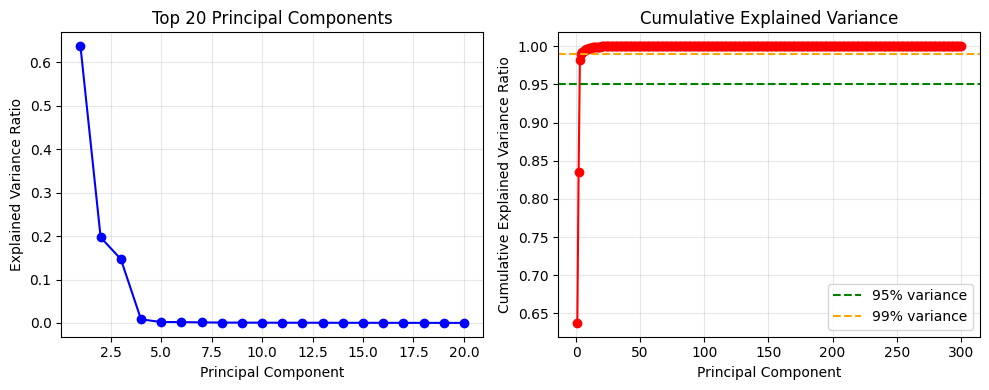

Final feature dimension after PCA: 300


In [7]:
print("Applying PCA dimensionality reduction...")

from sklearn.decomposition import PCA

# 设置目标维度（从937维降到300维）
target_dim = 300
print(f"Reducing features from {X_combined.shape[1]} to {target_dim} dimensions")

# 应用PCA降维
pca = PCA(n_components=target_dim, random_state=42)
X_combined_pca = pca.fit_transform(X_combined)

# 计算解释方差比例
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print(f"PCA reduction completed!")
print(f"Explained variance ratio: {explained_variance_ratio.sum():.4f}")
print(f"Top 10 components explain: {cumulative_variance_ratio[:10]}")

# 可视化PCA解释方差
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, min(21, target_dim+1)), explained_variance_ratio[:20], 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Top 20 Principal Components')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, target_dim+1), cumulative_variance_ratio, 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% variance')
plt.legend()

plt.tight_layout()
plt.show()

# 使用降维后的特征
X_combined = X_combined_pca
print(f"Final feature dimension after PCA: {X_combined.shape[1]}")

4: NNLS β/α Label Generation (Based on Area Ratio)

In [8]:
print("Generating β/α ratio labels using decomposed spectra...")

# 方法1：直接从分解光谱计算面积比例（更准确）
def calculate_area_ratio_from_decomposed(alpha_helix, beta_sheet_lo, beta_sheet_hi, 
                                       beta_turn_lo, beta_turn_hi, wavenumber_axis):
    """
    从分解后的光谱直接计算β/α面积比例
    """
    ratios = []
    valid_indices = []
    
    for idx in range(len(alpha_helix)):
        # 计算α螺旋的总面积
        alpha_area = np.trapz(alpha_helix[idx], wavenumber_axis)
        
        # 计算β结构的总面积（β折叠 + β转角）
        beta_sheet_area = np.trapz(beta_sheet_lo[idx], wavenumber_axis) + np.trapz(beta_sheet_hi[idx], wavenumber_axis)
        beta_turn_area = np.trapz(beta_turn_lo[idx], wavenumber_axis) + np.trapz(beta_turn_hi[idx], wavenumber_axis)
        beta_total_area = beta_sheet_area + beta_turn_area
        
        # 避免除零
        if alpha_area > 1e-8:
            ratio = beta_total_area / alpha_area
            ratios.append(ratio)
            valid_indices.append(idx)
        else:
            print(f"Warning: Sample {idx} has zero alpha helix area")
    
    return np.array(ratios), np.array(valid_indices)

# 方法2：使用NNLS拟合的传统方法（作为对比）
def calculate_area_ratio_from_nnls(composite, wavenumber_axis, peak_table):
    """
    使用NNLS拟合计算β/α面积比例（传统方法）
    """
    alpha_areas, beta_areas, ratios, valid_indices = [], [], [], []
    
    for idx, y in enumerate(composite):
        peak_indices, y_smooth = detect_peaks(y, wavenumber_axis)
        detected_positions = wavenumber_axis[peak_indices]
        selected_centers, selected_types, selected_gammas = [], [], []
        
        for p in detected_positions:
            fam, gamma = classify_peak(p, peak_table)
            if fam is not None:
                selected_centers.append(p)
                selected_types.append(fam)
                selected_gammas.append(gamma)
        
        selected_centers = np.array(selected_centers)
        selected_types = np.array(selected_types)
        selected_gammas = np.array(selected_gammas)
        
        if len(selected_centers) == 0 or not np.any(selected_types == 'alpha_helix'):
            continue
            
        B = np.stack([lorentzian(wavenumber_axis, c, g) for c, g in zip(selected_centers, selected_gammas)], axis=1)
        B /= B.max(axis=0, keepdims=True)
        res = lsq_linear(B, y, bounds=(0, np.inf), lsq_solver='exact')
        amplitudes = res.x
        
        # 计算每个峰值的面积
        areas = lorentzian_area(amplitudes, selected_gammas)
        
        # 计算α和β区域的总面积
        alpha_area = areas[selected_types == 'alpha_helix'].sum()
        beta_area = areas[(selected_types == 'beta_sheet') | (selected_types == 'beta_turn')].sum()
        
        if alpha_area <= 1e-8:
            continue
            
        alpha_areas.append(alpha_area)
        beta_areas.append(beta_area)
        ratios.append(beta_area / alpha_area)
        valid_indices.append(idx)
    
    return np.array(ratios), np.array(valid_indices)

# 使用分解光谱方法生成标签（推荐）
y_decomposed, valid_indices_decomposed = calculate_area_ratio_from_decomposed(
    alpha_helix, beta_sheet_lo, beta_sheet_hi, beta_turn_lo, beta_turn_hi, wavenumber_axis
)

# 使用NNLS方法生成标签（作为对比）
y_nnls, valid_indices_nnls = calculate_area_ratio_from_nnls(composite, wavenumber_axis, peak_table)

print(f"Decomposed method: {len(y_decomposed)} valid samples, ratio range: {y_decomposed.min():.3f} - {y_decomposed.max():.3f}")
print(f"NNLS method: {len(y_nnls)} valid samples, ratio range: {y_nnls.min():.3f} - {y_nnls.max():.3f}")

# 选择使用哪种方法（推荐使用分解光谱方法）
use_decomposed_method = True

if use_decomposed_method:
    y = y_decomposed
    valid_indices = valid_indices_decomposed
    print("Using decomposed spectra method for label generation")
else:
    y = y_nnls
    valid_indices = valid_indices_nnls
    print("Using NNLS method for label generation")

# 对比例取对数（用于回归）
y = np.log1p(y)
print(f"Log-transformed labels: range {y.min():.3f} - {y.max():.3f}")

Generating β/α ratio labels using decomposed spectra...


/scratch/9844596.1.academic-gpu/ipykernel_3530993/3744228112.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_area = np.trapz(alpha_helix[idx], wavenumber_axis)
/scratch/9844596.1.academic-gpu/ipykernel_3530993/3744228112.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  beta_sheet_area = np.trapz(beta_sheet_lo[idx], wavenumber_axis) + np.trapz(beta_sheet_hi[idx], wavenumber_axis)
/scratch/9844596.1.academic-gpu/ipykernel_3530993/3744228112.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  beta_turn_area = np.trapz(beta_turn_lo[idx], wavenumber_axis) + np.trapz(beta_turn_hi[idx], wavenumber_axis)


Decomposed method: 10000 valid samples, ratio range: 1.782 - 6.966
NNLS method: 9545 valid samples, ratio range: 0.000 - 7.278
Using decomposed spectra method for label generation
Log-transformed labels: range 1.023 - 2.075


4.5: Label Distribution Analysis

Analyzing label distribution...


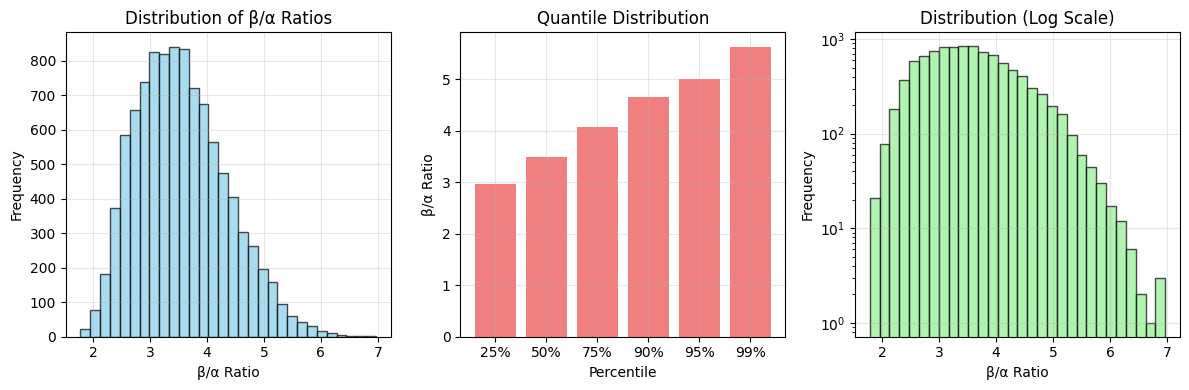

β/α Ratio Statistics:
  Mean: 3.558
  Std: 0.795
  Min: 1.782
  Max: 6.966
  25th percentile: 2.957
  50th percentile: 3.482
  75th percentile: 4.071
  90th percentile: 4.649
  95th percentile: 5.000
  99th percentile: 5.628

Data Balance Analysis:
  High β/α ratio samples (> 4.649): 1000 (10.0%)
  Low β/α ratio samples (≤ 4.649): 9000 (90.0%)


In [9]:
print("Analyzing label distribution...")

def analyze_label_distribution(y):
    """
    分析标签分布，识别数据不平衡问题
    """
    # 转换回原始比例（去掉log1p）
    original_ratios = np.expm1(y)
    
    plt.figure(figsize=(12, 4))
    
    # 直方图
    plt.subplot(1, 3, 1)
    plt.hist(original_ratios, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('β/α Ratio')
    plt.ylabel('Frequency')
    plt.title('Distribution of β/α Ratios')
    plt.grid(True, alpha=0.3)
    
    # 分位数图
    plt.subplot(1, 3, 2)
    quantiles = np.percentile(original_ratios, [25, 50, 75, 90, 95, 99])
    plt.bar(range(len(quantiles)), quantiles, color='lightcoral')
    plt.xlabel('Percentile')
    plt.ylabel('β/α Ratio')
    plt.title('Quantile Distribution')
    plt.xticks(range(len(quantiles)), ['25%', '50%', '75%', '90%', '95%', '99%'])
    plt.grid(True, alpha=0.3)
    
    # 对数尺度直方图
    plt.subplot(1, 3, 3)
    plt.hist(original_ratios, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    plt.xlabel('β/α Ratio')
    plt.ylabel('Frequency')
    plt.title('Distribution (Log Scale)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"β/α Ratio Statistics:")
    print(f"  Mean: {original_ratios.mean():.3f}")
    print(f"  Std: {original_ratios.std():.3f}")
    print(f"  Min: {original_ratios.min():.3f}")
    print(f"  Max: {original_ratios.max():.3f}")
    print(f"  25th percentile: {quantiles[0]:.3f}")
    print(f"  50th percentile: {quantiles[1]:.3f}")
    print(f"  75th percentile: {quantiles[2]:.3f}")
    print(f"  90th percentile: {quantiles[3]:.3f}")
    print(f"  95th percentile: {quantiles[4]:.3f}")
    print(f"  99th percentile: {quantiles[5]:.3f}")
    
    # 检查数据不平衡
    high_ratio_threshold = np.percentile(original_ratios, 90)  # 90%分位数作为高值阈值
    high_ratio_count = np.sum(original_ratios > high_ratio_threshold)
    high_ratio_percentage = high_ratio_count / len(original_ratios) * 100
    
    print(f"\nData Balance Analysis:")
    print(f"  High β/α ratio samples (> {high_ratio_threshold:.3f}): {high_ratio_count} ({high_ratio_percentage:.1f}%)")
    print(f"  Low β/α ratio samples (≤ {high_ratio_threshold:.3f}): {len(original_ratios) - high_ratio_count} ({100-high_ratio_percentage:.1f}%)")
    
    if high_ratio_percentage < 10:
        print(f"  ⚠️  Warning: High β/α ratio samples are underrepresented!")
        print(f"  💡  Consider using weighted loss function or data augmentation")
    
    return original_ratios, high_ratio_threshold

# 分析标签分布
original_ratios, high_ratio_threshold = analyze_label_distribution(y)

4.6: Feature Selection Based on Importance

Performing feature selection based on importance...
Training Random Forest to evaluate feature importance...
Feature selection completed!
Selected 100 most important features out of 300
Final feature dimension after selection: 100


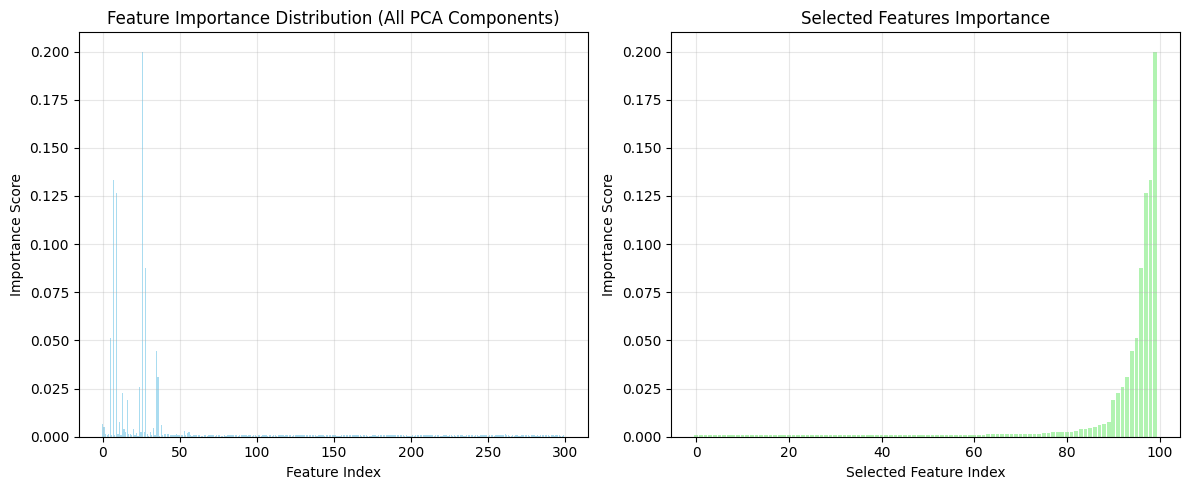

Top 10 most important features:
  Feature  69: 0.000744
  Feature  71: 0.000747
  Feature 185: 0.000749
  Feature 214: 0.000750
  Feature 138: 0.000751
  Feature 259: 0.000751
  Feature 148: 0.000753
  Feature  60: 0.000753
  Feature 122: 0.000757
  Feature 156: 0.000759


In [10]:
print("Performing feature selection based on importance...")

def select_important_pca_features(X_pca, y, n_components=100):
    """
    在PCA降维后，基于重要性选择最重要的主成分
    """
    from sklearn.ensemble import RandomForestRegressor
    
    print(f"Training Random Forest to evaluate feature importance...")
    
    # 训练随机森林评估特征重要性
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_pca, y)
    
    # 获取特征重要性
    importance = rf.feature_importances_
    
    # 选择最重要的n_components个特征
    top_indices = importance.argsort()[-n_components:]
    X_selected = X_pca[:, top_indices]
    
    print(f"Feature selection completed!")
    print(f"Selected {n_components} most important features out of {X_pca.shape[1]}")
    
    return X_selected, top_indices, importance

# 选择最重要的100个特征
X_combined_selected, selected_indices, feature_importance = select_important_pca_features(
    X_combined, y, n_components=100
)

# 更新特征矩阵
X_combined = X_combined_selected
print(f"Final feature dimension after selection: {X_combined.shape[1]}")

# 可视化特征重要性分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(feature_importance)), feature_importance, alpha=0.7, color='skyblue')
plt.xlabel('Feature Index')
plt.ylabel('Importance Score')
plt.title('Feature Importance Distribution (All PCA Components)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
selected_importance = feature_importance[selected_indices]
plt.bar(range(len(selected_importance)), selected_importance, alpha=0.7, color='lightgreen')
plt.xlabel('Selected Feature Index')
plt.ylabel('Importance Score')
plt.title('Selected Features Importance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Top 10 most important features:")
for i in range(min(10, len(selected_indices))):
    idx = selected_indices[i]
    importance = feature_importance[idx]
    print(f"  Feature {idx:3d}: {importance:.6f}")

5: Normalization and Splitting

In [11]:
print("Validating and preprocessing data...")

# 验证数据完整性
if len(valid_indices) == 0:
    raise ValueError("No valid samples found! Check your data and peak definitions.")

print(f"Valid samples: {len(valid_indices)} out of {N} total samples")

# 提取有效样本的特征和光谱
X_combined_valid = X_combined[valid_indices]
composite_valid = composite[valid_indices]

# 验证特征维度
print(f"Feature matrix shape: {X_combined_valid.shape}")
print(f"Spectra matrix shape: {composite_valid.shape}")
print(f"Labels shape: {y.shape}")

# 检查是否有NaN或无穷大值
if np.any(np.isnan(X_combined_valid)) or np.any(np.isinf(X_combined_valid)):
    print("Warning: Found NaN or infinite values in features, cleaning...")
    X_combined_valid = np.nan_to_num(X_combined_valid, nan=0.0, posinf=0.0, neginf=0.0)

if np.any(np.isnan(composite_valid)) or np.any(np.isinf(composite_valid)):
    print("Warning: Found NaN or infinite values in spectra, cleaning...")
    composite_valid = np.nan_to_num(composite_valid, nan=0.0, posinf=0.0, neginf=0.0)

if np.any(np.isnan(y)) or np.any(np.isinf(y)):
    print("Warning: Found NaN or infinite values in labels, cleaning...")
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

# 光谱标准化
mean_spec = composite_valid.mean()
std_spec = composite_valid.std()
if std_spec < 1e-8:
    print("Warning: Very small standard deviation in spectra, using identity normalization")
    X_spectra_norm = composite_valid - mean_spec
else:
    X_spectra_norm = (composite_valid - mean_spec) / std_spec

print(f"Spectra normalization: mean={mean_spec:.6f}, std={std_spec:.6f}")

# 特征标准化（可选）
feature_mean = X_combined_valid.mean(axis=0)
feature_std = X_combined_valid.std(axis=0)
feature_std[feature_std < 1e-8] = 1.0  # 避免除零
X_features_norm = (X_combined_valid - feature_mean) / feature_std

print(f"Feature normalization: mean range [{feature_mean.min():.6f}, {feature_mean.max():.6f}]")
print(f"Feature normalization: std range [{feature_std.min():.6f}, {feature_std.max():.6f}]")

# 数据分割
X_train_spec, X_test_spec, X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    X_spectra_norm, X_features_norm, y, test_size=0.15, random_state=42, stratify=None
)
X_train_spec, X_val_spec, X_train_feat, X_val_feat, y_train, y_val = train_test_split(
    X_train_spec, X_train_feat, y_train, test_size=0.15/0.85, random_state=42, stratify=None
)

print(f"Training set: {len(X_train_spec)} samples")
print(f"Validation set: {len(X_val_spec)} samples") 
print(f"Test set: {len(X_test_spec)} samples")


Validating and preprocessing data...
Valid samples: 10000 out of 10000 total samples
Feature matrix shape: (10000, 100)
Spectra matrix shape: (10000, 1601)
Labels shape: (10000,)
Spectra normalization: mean=0.606176, std=0.502339
Feature normalization: mean range [-0.000000, 0.000000]
Feature normalization: std range [0.012591, 867.613431]
Training set: 7000 samples
Validation set: 1500 samples
Test set: 1500 samples


6: Dataset & Dataloader

In [12]:
class EarlyFusionDataset(Dataset):
    def __init__(self, X_spec, X_feat, y):
        self.spec = torch.from_numpy(X_spec).float().unsqueeze(1)
        self.feat = torch.from_numpy(X_feat).float()
        self.label = torch.from_numpy(y).float().unsqueeze(1)
    def __len__(self): return len(self.spec)
    def __getitem__(self, idx): return self.spec[idx], self.feat[idx], self.label[idx]
train_ds = EarlyFusionDataset(X_train_spec, X_train_feat, y_train)
val_ds   = EarlyFusionDataset(X_val_spec, X_val_feat, y_val)
test_ds  = EarlyFusionDataset(X_test_spec, X_test_feat, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

7: Wider and Deeper CNN + Multi-head LayerNorm Attention Early Fusion Model

In [13]:
class MultiHeadSelfAttention1D(nn.Module):
    def __init__(self, d_model, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.qkv_proj = nn.Linear(d_model, d_model * 3)
        self.fc_out = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):  # x: (B, L, d_model)
        B, L, D = x.shape
        qkv = self.qkv_proj(x).reshape(B, L, 3, self.n_heads, D // self.n_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2,-1)) / np.sqrt(D//self.n_heads)
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1,2).reshape(B, L, D)
        out = self.fc_out(out)
        return self.norm(out + x)  # Residual + normalization

class EarlyFusionNet(nn.Module):
    def __init__(self, input_spec_len, input_feat_len):
        super().__init__()
        # Wider and deeper CNN branch
        self.cnn_branch = nn.Sequential(
            nn.Conv1d(1, 128, 11, padding=5),
            nn.ReLU(),
            nn.Conv1d(128, 256, 7, padding=3),
            nn.ReLU(),
            nn.Conv1d(256, 512, 5, padding=2),
            nn.ReLU(),
            nn.Conv1d(512, 512, 3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(32)
        self.attn = MultiHeadSelfAttention1D(512, n_heads=4)
        self.flatten = nn.Flatten()
        self.cnn_fc = nn.Sequential(
            nn.Linear(512*32, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        # Deeper MLP branch + Dropout
        self.mlp_branch = nn.Sequential(
            nn.Linear(input_feat_len, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.fusion = nn.Sequential(
            nn.Linear(64+16, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, spec, feat):
        x = self.cnn_branch(spec)              # (B, 512, L)
        x = self.pool(x)                       # (B, 512, 32)
        x = x.permute(0,2,1)                   # (B, 32, 512)
        x = self.attn(x)                       # (B, 32, 512)
        x = x.permute(0,2,1).contiguous().view(x.size(0), -1)  # (B, 512*32)
        x = self.cnn_fc(x)                     # (B, 64)
        y = self.mlp_branch(feat)              # (B, 16)
        out = torch.cat([x, y], dim=1)
        return self.fusion(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EarlyFusionNet(input_spec_len=X_spectra_norm.shape[1], input_feat_len=X_combined_valid.shape[1]).to(device)


8: Training Main Loop

Epoch   1/500 | Train loss: 0.06289 | Val loss: 0.04855
Epoch  10/500 | Train loss: 0.00196 | Val loss: 0.10463
Epoch  20/500 | Train loss: 0.00149 | Val loss: 0.08253
Epoch  30/500 | Train loss: 0.00099 | Val loss: 0.07739
Epoch  40/500 | Train loss: 0.00093 | Val loss: 0.06350
Epoch  50/500 | Train loss: 0.00063 | Val loss: 0.06281
Epoch  60/500 | Train loss: 0.00065 | Val loss: 0.06045
Epoch  70/500 | Train loss: 0.00057 | Val loss: 0.05844
Epoch  80/500 | Train loss: 0.00486 | Val loss: 0.04376
Epoch  90/500 | Train loss: 0.00052 | Val loss: 0.05643
Epoch 100/500 | Train loss: 0.00048 | Val loss: 0.05349
Epoch 110/500 | Train loss: 0.00050 | Val loss: 0.04367
Epoch 120/500 | Train loss: 0.00041 | Val loss: 0.04434
Epoch 130/500 | Train loss: 0.00045 | Val loss: 0.04387
Epoch 140/500 | Train loss: 0.00041 | Val loss: 0.04233
Epoch 150/500 | Train loss: 0.00038 | Val loss: 0.03910
Epoch 160/500 | Train loss: 0.00037 | Val loss: 0.03974
Epoch 170/500 | Train loss: 0.00031 | Val loss: 

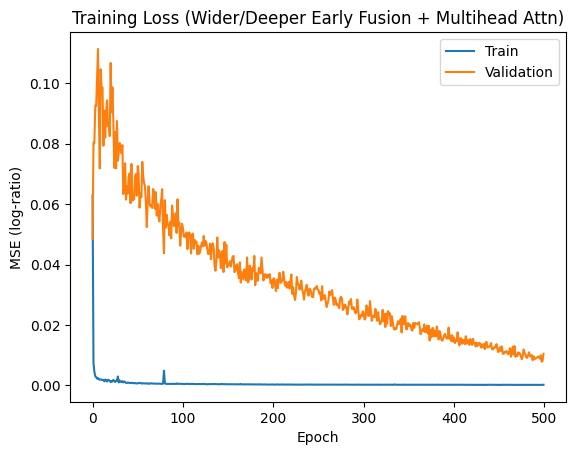

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
num_epochs = 500
train_losses, val_losses = [], []
for epoch in range(1, num_epochs+1):
    model.train()
    train_loss = 0.0
    for spec, feat, yb in train_loader:
        spec, feat, yb = spec.to(device), feat.to(device), yb.to(device)
        pred = model(spec, feat)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(yb)
    train_loss /= len(train_ds)
    train_losses.append(train_loss)
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for spec, feat, yb in val_loader:
            spec, feat, yb = spec.to(device), feat.to(device), yb.to(device)
            pred = model(spec, feat)
            loss = loss_fn(pred, yb)
            val_loss += loss.item() * len(yb)
    val_loss /= len(val_ds)
    val_losses.append(val_loss)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs} | Train loss: {train_loss:.5f} | Val loss: {val_loss:.5f}")
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch"); plt.ylabel("MSE (log-ratio)")
plt.title("Training Loss (Wider/Deeper Early Fusion + Multihead Attn)")
plt.legend(); plt.show()

9: Test Evaluation, Binned MAE/Quantile Error/Coarse Classification Accuracy

Validation (Wider/Deeper + Multihead Attn): MAE=0.439, R2=0.597


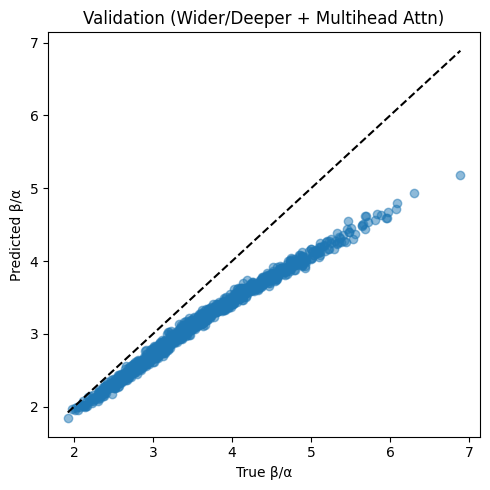

Test (Wider/Deeper + Multihead Attn): MAE=0.434, R2=0.609


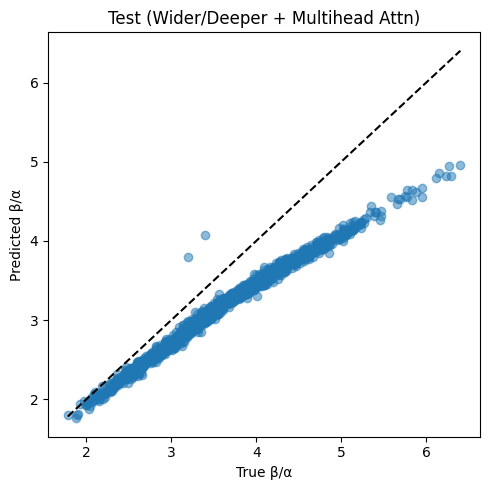

Range [0, 2): MAE = 0.042, count=2
Range [2, 3): MAE = 0.218, count=391
Range [3, 4): MAE = 0.386, count=702
Range [4, 5): MAE = 0.681, count=338
Range [5, 7): MAE = 1.065, count=67
Coarse classification accuracy: 58.4%
Confusion matrix:
 [[  2   0   0   0   0]
 [  5 386   0   0   0]
 [  0 247 455   0   0]
 [  0   0 306  32   0]
 [  0   0   0  66   1]]
Val | 50th percentile absolute error: 0.387
Val | 75th percentile absolute error: 0.551
Val | 90th percentile absolute error: 0.765
Val | 95th percentile absolute error: 0.906
Val | 99th percentile absolute error: 1.161


In [15]:
def get_preds(loader):
    model.eval()
    ys, y_preds = [], []
    with torch.no_grad():
        for spec, feat, y in loader:
            spec, feat = spec.to(device), feat.to(device)
            pred = model(spec, feat).cpu().numpy()
            ys.append(y.numpy())
            y_preds.append(pred)
    ys = np.concatenate(ys).flatten()
    y_preds = np.concatenate(y_preds).flatten()
    return np.expm1(ys), np.expm1(y_preds)
y_val_true, y_val_pred = get_preds(val_loader)
y_test_true, y_test_pred = get_preds(test_loader)

def report(y_true, y_pred, title):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{title}: MAE={mae:.3f}, R2={r2:.3f}")
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
    plt.xlabel("True β/α")
    plt.ylabel("Predicted β/α")
    plt.title(title)
    plt.tight_layout()
    plt.show()
report(y_val_true, y_val_pred, "Validation (Wider/Deeper + Multihead Attn)")
report(y_test_true, y_test_pred, "Test (Wider/Deeper + Multihead Attn)")

# --------- Binned MAE / Coarse Classification Accuracy ----------
def binned_mae_acc(y_true, y_pred, bins=[2,3,4,5,7]):
    y_true_bin = np.digitize(y_true, bins)
    y_pred_bin = np.digitize(y_pred, bins)
    for i in range(len(bins)):
        idx = (y_true_bin == i)
        if np.any(idx):
            print(f"Range [{bins[i-1] if i>0 else 0}, {bins[i]}): MAE = {mean_absolute_error(y_true[idx], y_pred[idx]):.3f}, count={idx.sum()}")
    acc = (y_true_bin == y_pred_bin).mean()
    print(f"Coarse classification accuracy: {acc*100:.1f}%")
    cm = confusion_matrix(y_true_bin, y_pred_bin)
    print("Confusion matrix:\n", cm)
binned_mae_acc(y_val_true, y_val_pred)
# --------- Quantile Error ----------
for p in [50,75,90,95,99]:
    e = np.abs(y_val_true-y_val_pred)
    print(f"Val | {p}th percentile absolute error: {np.percentile(e,p):.3f}")

9.5: Save Trained Model

In [16]:
# Save model and related information
model_save_path = 'best_early_fusion_model_4PCA+selection.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    
    # 数据预处理信息
    'mean_spec': mean_spec,
    'std_spec': std_spec,
    'feature_mean': feature_mean,
    'feature_std': feature_std,
    
    # 数据集信息
    'wavenumber_axis': wavenumber_axis,
    'peak_table_flat': peak_table_flat,
    'peak_table': peak_table,
    'dataset_info': {
        'dataset_name': 'dataset2.npz',
        'total_samples': N,
        'valid_samples': len(valid_indices),
        'wavenumber_points': L,
        'wavenumber_range': [wavenumber_axis.min(), wavenumber_axis.max()],
        'label_method': 'decomposed_spectra' if use_decomposed_method else 'nnls_fitting',
        'label_range': [np.expm1(y.min()), np.expm1(y.max())]
    },
    
    # 特征信息
    'feature_info': {
        'integral_features': X_integral.shape[1],
        'decomposed_features': X_decomposed.shape[1],
        'nnls_features': X_nnls.shape[1],
        'total_features': X_combined_valid.shape[1]
    },
    
    # 模型配置
    'model_config': {
        'input_spec_len': X_spectra_norm.shape[1],
        'input_feat_len': X_combined_valid.shape[1],
        'architecture': 'EarlyFusionNet_with_MultiHeadAttention',
        'cnn_channels': [1, 128, 256, 512, 512],
        'attention_heads': 4,
        'mlp_hidden_dims': [64, 32, 16]
    }
}, model_save_path)

print(f"Model saved to: {model_save_path}")
print(f"Model configuration: spectral length={X_spectra_norm.shape[1]}, feature length={X_combined_valid.shape[1]}")

# Save comprehensive results
results_save_path = 'model_results_dataset2.npz'
np.savez(results_save_path,
    # 预测结果
    y_val_true=y_val_true,
    y_val_pred=y_val_pred,
    y_test_true=y_test_true,
    y_test_pred=y_test_pred,
    
    # 训练历史
    train_losses=train_losses,
    val_losses=val_losses,
    
    # 数据统计
    feature_importance=np.abs(model.mlp_branch[0].weight.data.mean(dim=0).cpu().numpy()),
    feature_names=[f"feature_{i}" for i in range(X_combined_valid.shape[1])],
    
    # 数据集信息
    dataset_info={
        'dataset_name': 'dataset2.npz',
        'total_samples': N,
        'valid_samples': len(valid_indices),
        'wavenumber_points': L,
        'wavenumber_range': [wavenumber_axis.min(), wavenumber_axis.max()],
        'label_method': 'decomposed_spectra' if use_decomposed_method else 'nnls_fitting'
    }
)

print(f"Comprehensive results saved to: {results_save_path}")

# 保存特征重要性分析
feature_importance = np.abs(model.mlp_branch[0].weight.data.mean(dim=0).cpu().numpy())
feature_indices = np.argsort(feature_importance)[::-1]

print("\nTop 20 most important features:")
for i in range(min(20, len(feature_indices))):
    idx = feature_indices[i]
    importance = feature_importance[idx]
    print(f"  Feature {idx:3d}: {importance:.6f}")

# 保存特征重要性到文件
np.save('feature_importance_dataset2.npy', {
    'importance_scores': feature_importance,
    'sorted_indices': feature_indices,
    'feature_names': [f"feature_{i}" for i in range(len(feature_importance))]
})
print("Feature importance saved to: feature_importance_dataset2.npy")

Model saved to: best_early_fusion_model_4PCA+selection.pth
Model configuration: spectral length=1601, feature length=100
Comprehensive results saved to: model_results_dataset2.npz

Top 20 most important features:
  Feature  99: 0.486985
  Feature  96: 0.278467
  Feature  94: 0.274442
  Feature  92: 0.266902
  Feature  93: 0.204268
  Feature  90: 0.184329
  Feature  98: 0.177278
  Feature  97: 0.140047
  Feature  87: 0.095659
  Feature  71: 0.074650
  Feature  86: 0.072976
  Feature  63: 0.066420
  Feature  74: 0.062961
  Feature  80: 0.060322
  Feature  79: 0.059947
  Feature  81: 0.059270
  Feature  70: 0.056335
  Feature  88: 0.051676
  Feature  67: 0.048626
  Feature  72: 0.043313
Feature importance saved to: feature_importance_dataset2.npy


10: Attention Visualization (CNN Branch)

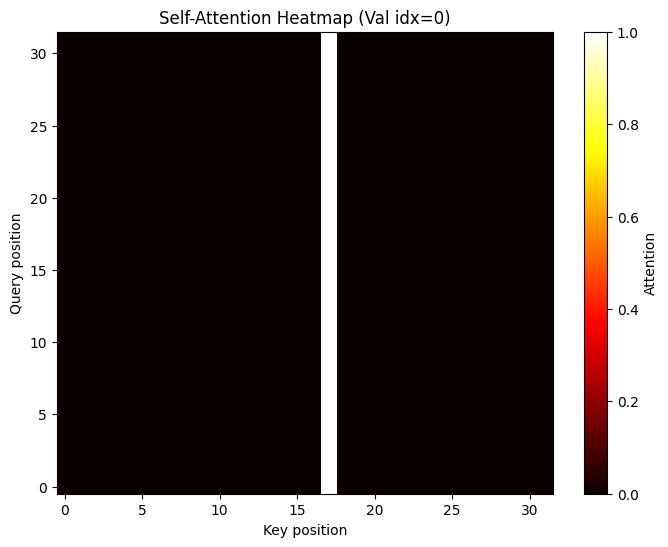

In [17]:
def plot_attention_heatmap(spec_idx):
    model.eval()
    with torch.no_grad():
        spec = torch.from_numpy(X_val_spec[spec_idx:spec_idx+1]).float().unsqueeze(1).to(device)
        feat = torch.from_numpy(X_val_feat[spec_idx:spec_idx+1]).float().to(device)
        x = model.cnn_branch(spec)
        x = model.pool(x)
        x = x.permute(0,2,1)
        attn_in = x
        attn_weights = model.attn.qkv_proj(attn_in).reshape(1, 32, 3, 4, 128).permute(2,0,3,1,4)
        q, k, v = attn_weights[0], attn_weights[1], attn_weights[2]
        score = (q @ k.transpose(-2,-1)) / np.sqrt(128)
        attn = score.softmax(dim=-1).cpu().numpy()[0,0]  # Take first head (L,L)
        plt.figure(figsize=(8,6))
        plt.imshow(attn, aspect='auto', origin='lower', cmap='hot')
        plt.colorbar(label="Attention")
        plt.xlabel("Key position"); plt.ylabel("Query position")
        plt.title(f"Self-Attention Heatmap (Val idx={spec_idx})")
        plt.show()

plot_attention_heatmap(0)

11: Visualize Single Spectrum Prediction

Val idx=22 | True β/α: 3.32 | Pred: 2.99


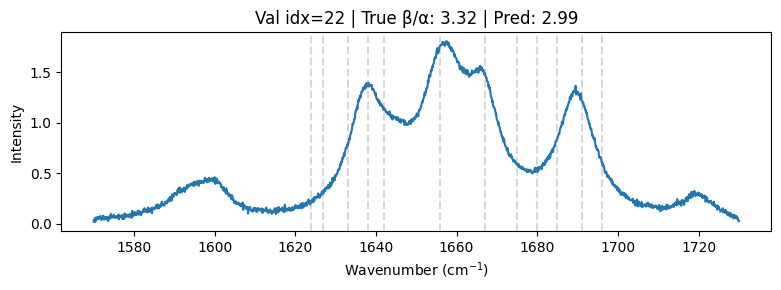

Val idx=1298 | True β/α: 3.55 | Pred: 3.13


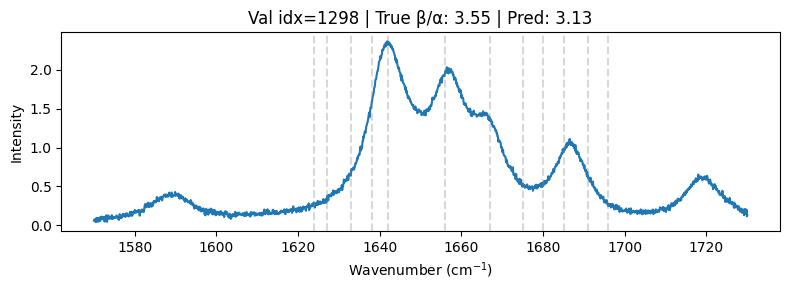

Val idx=943 | True β/α: 3.79 | Pred: 3.30


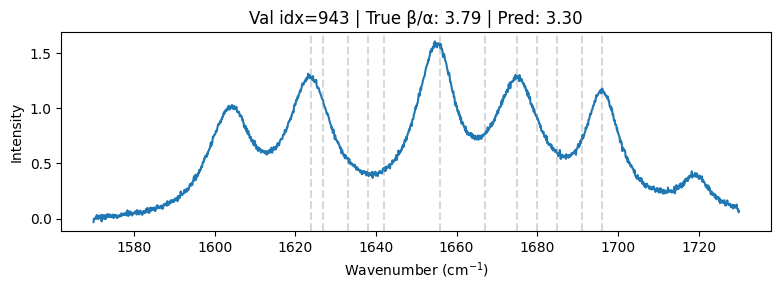

Val idx=989 | True β/α: 4.24 | Pred: 3.67


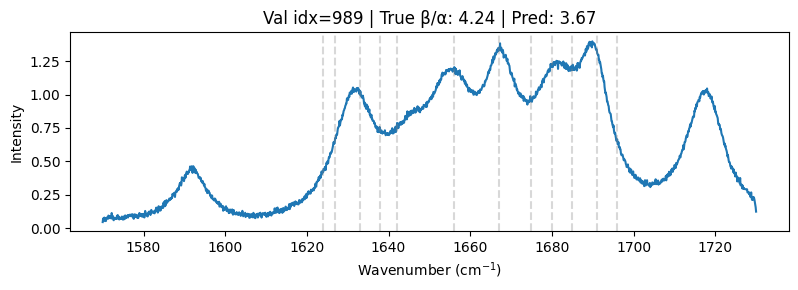

Val idx=419 | True β/α: 2.50 | Pred: 2.36


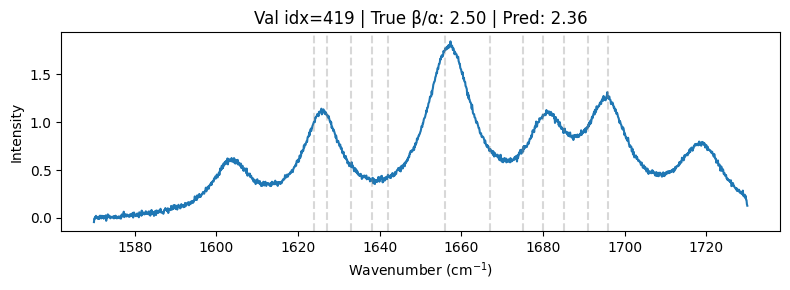

In [18]:
indices = np.random.choice(len(X_val_spec), size=5, replace=False)
for i in indices:
    print(f"Val idx={i} | True β/α: {y_val_true[i]:.2f} | Pred: {y_val_pred[i]:.2f}")
    plt.figure(figsize=(8,3))
    plt.plot(wavenumber_axis, X_val_spec[i].squeeze() * std_spec + mean_spec, label="Spectrum (unnormed)")
    for j, (_, center) in enumerate(peak_table_flat):
        plt.axvline(center, color='gray', ls='--', alpha=0.3)
    plt.xlabel("Wavenumber (cm$^{-1}$)")
    plt.ylabel("Intensity")
    plt.title(f"Val idx={i} | True β/α: {y_val_true[i]:.2f} | Pred: {y_val_pred[i]:.2f}")
    plt.tight_layout()
    plt.show()